In [10]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

ROOT = Path("/Users/alexgonzalez/Documents/nba_quant")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.minutes import (
    TIER1_MINUTES_FEATURES,
    add_minutes_features,
)
from src.models.xgboost_models import (
    DEFAULT_MINUTES_FEATURES,
    XGBoostConfig,
    XGBoostMinutesModel,
)
from src.models.xgboost_models.tuning import tune_minutes

In [25]:
s20 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2019-20/regular_season/player_gamelogs.parquet')
s21 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2020-21/regular_season/player_gamelogs.parquet')
s22 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2021-22/regular_season/player_gamelogs.parquet')
s23 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2022-23/regular_season/player_gamelogs.parquet')
s24 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2023-24/regular_season/player_gamelogs.parquet')
s25 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2024-25/regular_season/player_gamelogs.parquet')
s26 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2025-26/regular_season/player_gamelogs.parquet')
df = pd.concat([s20, s21, s22, s23, s24, s25, s26])
df['starting'] = (
    df['start_position'].astype('string').str.strip().isin(['G', 'F', 'C']).astype(int)
)

print(f"Number of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
df.sample(5)

Number of rows: 176738
Number of columns: 190


,season_year,player_id,player_name,nickname,team_id,team_abbreviation,team_name,game_id,game_date,matchup,wl,min,fgm,fga,fg_pct,fg3_m,fg3_a,fg3_pct,ftm,fta,ft_pct,oreb,dreb,reb,ast,tov,stl,blk,blka,pf,pfd,pts,plus_minus,nba_fantasy_pts,dd2,td3,wnba_fantasy_pts,fp_high_score,available_flag,min_sec,team_count,e_off_rating,off_rating,sp_work_off_rating,e_def_rating,def_rating,sp_work_def_rating,e_net_rating,net_rating,sp_work_net_rating,ast_pct,ast_to,ast_ratio,oreb_pct,dreb_pct,reb_pct,tm_tov_pct,e_tov_pct,efg_pct,ts_pct,usg_pct,e_usg_pct,e_pace,pace,pace_per40,sp_work_pace,pie,poss,fgm_pg,fga_pg,team_city,team_tricode,team_slug,first_name,family_name,name_i,player_slug,start_position,comment,jersey_num,minutes,spd,dist,orbc,drbc,rbc,tchs,sast,ftast,pass,assists,cfgm,cfga,cfg_pct,ufgm,ufga,uncontested_field_goals_percentage,field_goal_percentage,dfgm,dfga,dfg_pct,team_fgm,team_fga,team_fg_pct,team_fg3_m,team_fg3_a,team_fg3_pct,team_ftm,team_fta,team_ft_pct,team_oreb,team_dreb,team_reb,team_ast,team_tov,team_stl,team_blk,team_blka,team_pf,team_pfd,team_pts,team_plus_minus,team_e_off_rating,team_off_rating,team_e_def_rating,team_def_rating,team_e_net_rating,team_net_rating,team_ast_pct,team_ast_to,team_ast_ratio,team_oreb_pct,team_dreb_pct,team_reb_pct,team_tm_tov_pct,team_efg_pct,team_ts_pct,team_e_pace,team_pace,team_pace_per40,team_poss,team_pie,opp_team_id,opp_fgm,opp_fga,opp_fg_pct,opp_fg3_m,opp_fg3_a,opp_fg3_pct,opp_ftm,opp_fta,opp_ft_pct,opp_oreb,opp_dreb,opp_reb,opp_ast,opp_tov,opp_stl,opp_blk,opp_blka,opp_pf,opp_pfd,opp_pts,opp_plus_minus,opp_e_off_rating,opp_off_rating,opp_e_def_rating,opp_def_rating,opp_e_net_rating,opp_net_rating,opp_ast_pct,opp_ast_to,opp_ast_ratio,opp_oreb_pct,opp_dreb_pct,opp_reb_pct,opp_tm_tov_pct,opp_efg_pct,opp_ts_pct,opp_e_pace,opp_pace,opp_pace_per40,opp_poss,opp_pie,season_type,pos,game_total,team_spread,player_team_spread,starting
20453,2024-25,1642267,Bub Carrington,Bub,1610612764,WAS,Washington Wizards,0022400291,2024-11-27T00:00:00,WAS vs. LAC,L,18.983333,1,4,0.250,0,3,0.000,1,2,0.5,0,2,2,4,1,0,0,0,4,1,3,-18,10.4,0,0,9.0,13.0,1,18:59,1,77.5,78.0,78.0,124.1,122.0,122.0,-46.6,-43.9,-43.9,0.444,4.0,40.0,0.000,0.087,0.044,10.0,10.1,0.250,0.307,0.128,0.130,103.11,103.67,86.39,103.67,0.000,41,1.0,4.0,Washington,WAS,wizards,Bub,Carrington,B. Carrington,bub-carrington,,,8,18.983333,4.69,1.60,0,2,2,36,0,0,30,4,0,0,0.000,1,4,0.250,0.250,2,2,1.000,35,85,0.412,8,33,0.242,18,22,0.818,11,29,40,21,20.0,9,4,4,18,19,96,-25.0,92.6,93.2,117.5,118.6,-24.9,-25.4,0.600,1.05,15.1,0.300,0.681,0.485,0.194,0.459,0.507,103.3,102.5,85.42,103,0.363,1610612746,45,89,0.506,12,33,0.364,19,25,0.760,13,34,47,27,16.0,18,4,4,19,18,121,25.0,117.5,118.6,92.6,93.2,24.9,25.4,0.600,1.69,18.8,0.319,0.700,0.515,0.157,0.573,0.605,103.3,102.5,85.42,102,0.637,Regular Season,PG,225.0,9.0,9.0,0
17708,2025-26,1642883,Sion James,Sion,1610612766,CHA,Charlotte Hornets,0022500390,2025-12-20T00:00:00,CHA @ DET,L,22.045000,2,6,0.333,1,3,0.333,0,0,0.0,1,4,5,0,1,1,1,1,1,3,5,-22,16.0,0,0,15.0,16.0,1,22:03,1,56.4,54.7,54.7,95.9,98.1,98.1,-39.5,-43.4,-43.4,0.000,0.0,0.0,0.036,0.167,0.096,14.3,14.3,0.417,0.417,0.119,0.126,113.83,114.31,95.26,114.31,0.093,53,2.0,6.0,Charlotte,CHA,hornets,Sion,James,S. James,sion-james,,,4,22.045000,4.82,1.75,1,4,5,33,0,0,30,0,1,3,0.333,1,3,0.333,0.333,0,1,0.000,28,89,0.315,13,41,0.317,17,20,0.850,12,31,43,21,24.0,12,7,10,23,25,86,-26.0,78.3,80.4,101.7,106.7,-23.4,-26.3,0.750,0.88,14.3,0.302,0.564,0.424,0.224,0.388,0.440,109.9,106.0,88.33,107,0.319,1610612765,41,93,0.441,6,28,0.214,24,32,0.750,17,44,61,23,20.0,16,10,7,25,23,112,26.0,101.7,106.7,78.3,80.4,23.4,26.3,0.561,1.15,15.1,0.436,0.698,0.576,0.190,0.473,0.523,109.9,106.0,88.33,105,0.681,Regular Season,SG,234.5,-10.5,10.5,0
10421,2023-24,1630208,Nick Richards,Nick,1610612766,CHA,Charlotte Hornets,0022300713,2024-02-05T00:00:00,CHA vs. LAL,L,32.383333,1,4,0.250,0,0,0.000,2,2,1.0,1,8,9,1,1,0,1,0,3,3,4,-7,18.3,0,0,16.0,18.0,1,32:23,1,108.2,106.8,106.8,116.0,113.3,11

In [26]:
print(f"Total number of duplicates: {df.duplicated(subset=['game_id', 'player_id']).sum()}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df = add_minutes_features(df)

Total number of duplicates: 0
Rows: 176738
Columns: 190


In [27]:
# MIN_FEATURES = [
#     "starting",
#     "starter_roll10_pct",
#     "team_min_rank_l10",
#     "team_usg_pct_rank_l10",
#     "track_minutes_ewm_hl10",
#     "base_min_trend_5v20",
#     "base_min_lag1",
# ]

MIN_FEATURES = [
    "min_lag_1",
    "min_mean_20",
    "min_ewm_hl_3",
    "min_std_10",
    "starting",
    "start_rate_10",
    "season_appearances_prior",
    "season_min_mean",
    "season_min_std",
    "season_start_rate",
    "prior_season_min_mean",
    "prior_season_appearances",
    "current_team_min_mean",
    "current_team_rows_prior",
    "usg_wmean_10",
    "fga_per_min_10",
    "assists_per_min_10",
    "team_pace_mean_10",
    "team_net_rating_mean_10",
    "team_net_rating_season",
    "opp_pace_mean_10",
    "opp_net_rating_mean_10",
    "expected_possessions",
    "team_days_since_prev_game",
    "team_games_prev_3d",
    "player_days_since_appearance",
    "player_appearances_prev_7d",
    "is_home",
    "team_spread_canonical",
    "abs_spread",
    "implied_team_total",
    "min_mean_3_minus_10",
    "min_mean_10_minus_season",
    "start_rate_x_abs_spread",
    "min10_x_expected_possessions"
]
print(f"Number of features: {len(MIN_FEATURES)}")
MIN_FEATURES



Number of features: 38


['min_lag_1',
 'min_mean_3',
 'min_mean_10',
 'min_mean_20',
 'min_ewm_hl_3',
 'min_std_10',
 'starting',
 'start_rate_10',
 'season_rows_prior',
 'season_appearances_prior',
 'season_min_mean',
 'season_min_std',
 'season_start_rate',
 'prior_season_min_mean',
 'prior_season_appearances',
 'current_team_min_mean',
 'current_team_rows_prior',
 'usg_wmean_10',
 'fga_per_min_10',
 'assists_per_min_10',
 'team_pace_mean_10',
 'team_net_rating_mean_10',
 'team_net_rating_season',
 'opp_pace_mean_10',
 'opp_net_rating_mean_10',
 'expected_possessions',
 'team_days_since_prev_game',
 'team_games_prev_3d',
 'player_days_since_appearance',
 'player_appearances_prev_7d',
 'is_home',
 'team_spread_canonical',
 'abs_spread',
 'implied_team_total',
 'min_mean_3_minus_10',
 'min_mean_10_minus_season',
 'start_rate_x_abs_spread',
 'min10_x_expected_possessions']

In [28]:
# ── Prop-specific config (NBA MIN) ────────────────────────────────────────────

HOLDOUT_SEASON = "2025-26"
ID_COLS = ["game_id", "player_id", "season_year", "player_name", "game_date"]
TARGET_COL = "minutes"
ROLE_COL = "starting"

QUANTILES = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

XGB_PARAMS = dict(
    objective="reg:quantileerror",
    n_estimators=1695,
    max_depth=3,
    learning_rate=0.052852647946832816,
    subsample=0.5916232263322159,
    colsample_bytree=0.6284413523882679,
    reg_alpha=0.022871045941195746,
    reg_lambda=2.0960269065270034,
    min_child_weight=8,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=50,
)

MIN_TIERS = {
    "<15 min": lambda a: a < 15,
    "15-24 min": lambda a: (a >= 15) & (a < 24),
    "24-31 min": lambda a: (a >= 24) & (a < 31),
    "31+ min": lambda a: a >= 31,
}

ARTIFACT_STEM = "min_nba_model"

# ── Shared train/eval helpers ─────────────────────────────────────────────────
from models.shared.splits import prepare_splits
from models.shared.train import run_timeseries_cv, run_walk_forward, evaluate_holdout
from models.shared.analysis import run_feature_ablation, analyze_correlations
from models.shared.artifacts import save_model_bundle, load_model_bundle, predict_quantiles
from models.shared.metrics import interval_coverage, pinball_50, pinball_loss

In [29]:
df = df[(df['minutes'] > 0)]
print(f"After filtering minutes: {df[MIN_FEATURES].shape[0]} rows")


After filtering minutes: 176710 rows


In [30]:
splits = prepare_splits(
    df,
    holdout_season=HOLDOUT_SEASON,
    features=MIN_FEATURES,
    target_col=TARGET_COL,
    id_cols=ID_COLS,
    role_col=ROLE_COL,
    extra_keep=["minutes"],
)
ppm_df = splits["ppm_df"]
ppm_holdout = splits["ppm_holdout"]
X = splits["X"]
y = splits["y"]


Train pool (excl. 2025-26) : 150,062 rows
Holdout   (2025-26)        : 26,648 rows
Date range (train)   : 2019-10-22 → 2025-04-13
Date range (holdout) : 2025-10-21 → 2026-04-12


In [ ]:
# import importlib
# import models.shared.train as train

# importlib.reload(train)
# tune_xgb_quantile = train.tune_xgb_quantile

# result = tune_xgb_quantile(X, y, n_trials=100, n_splits=5)
# XGB_PARAMS = result["best_params"]

In [31]:
tscv_results = run_timeseries_cv(
    X, y, ppm_df,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    quantiles=QUANTILES,
)
wf = run_walk_forward(
    X, y, ppm_df,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    quantiles=QUANTILES,
)

wf_results = wf["wf_results"]
models_last = wf["models_last"]
preds_last = wf["preds_last"]
X_val_last = wf["X_val_last"]
y_val_last = wf["y_val_last"]
starting_last = wf["starting_last"]
last_fold = wf["last_fold"]


── Phase 1: TimeSeriesSplit ─────────────────────────────────────────

TSCV fold 1
  n=25010
  pinball  | q0.05=0.604  q0.10=1.005  q0.20=1.591  q0.30=1.968  q0.40=2.175  q0.50=2.240  q0.60=2.172  q0.70=1.966  q0.80=1.596  q0.90=1.015  q0.95=0.608
  coverage | 80%=78.4% (target 80%)  90%=89.2% (target 90%)
  Starters   | n=11705 | pinball q50: 2.102 | 80% coverage: 78.4%
  Bench      | n=13305 | pinball q50: 2.362 | 80% coverage: 78.4%
  <15 min    | n= 6127 | pinball q50: 2.496 | 80% coverage: 73.8%
  15-24 min  | n= 6737 | pinball q50: 2.214 | 80% coverage: 84.6%
  24-31 min  | n= 5715 | pinball q50: 2.179 | 80% coverage: 82.0%
  31+ min    | n= 6431 | pinball q50: 2.078 | 80% coverage: 73.1%

TSCV fold 2
  n=25010
  pinball  | q0.05=0.631  q0.10=1.048  q0.20=1.659  q0.30=2.042  q0.40=2.259  q0.50=2.328  q0.60=2.258  q0.70=2.040  q0.80=1.654  q0.90=1.043  q0.95=0.619
  coverage | 80%=77.7% (target 80%)  90%=88.8% (target 90%)
  Starters   | n=11827 | pinball q50: 2.179 | 80% coverage

### Evaluation

XGBoost quantile models only. Each split is scored with pinball loss at every trained quantile and with interval coverage for the 80% interval (q0.10–q0.90) and the 90% interval (q0.05–q0.95). The holdout also reports empirical calibration at each quantile, P(y ≤ q̂), interval sharpness as the mean and median width in minutes, the share of rows where a lower quantile exceeds a higher one, and minute tiers bucketed by predicted q50 rather than actual minutes.


In [32]:
def score_predictions(y_true, preds, split: str):
    """Pinball loss per quantile and central interval coverage."""
    y_true = np.asarray(y_true, dtype=float)
    pinball_rows = []
    for key, pred in preds.items():
        alpha = float(str(key).split("_", 1)[1])
        pinball_rows.append({
            "split": split,
            "quantile": alpha,
            "pinball": pinball_loss(y_true, pred, alpha),
        })
    coverage_rows = []
    for low, high, nominal in ((0.10, 0.90, 0.80), (0.05, 0.95, 0.90)):
        low_key, high_key = f"q_{low:.2f}", f"q_{high:.2f}"
        if low_key not in preds or high_key not in preds:
            continue
        coverage_rows.append({
            "split": split,
            "interval": f"{nominal:.0%}",
            "coverage": interval_coverage(y_true, preds[low_key], preds[high_key]),
            "target": nominal,
        })
    return pd.DataFrame(pinball_rows), pd.DataFrame(coverage_rows)


wf_pinball, wf_coverage = score_predictions(
    y_val_last, preds_last, last_fold["fold"]
)
display(wf_pinball.round(4))
display(wf_coverage.round(4))


,split,quantile,pinball
0,WF fold 4 (2024-03-17 → 2025-01-02),0.05,0.6067
1,WF fold 4 (2024-03-17 → 2025-01-02),0.10,1.0111
2,WF fold 4 (2024-03-17 → 2025-01-02),0.20,1.5868
3,WF fold 4 (2024-03-17 → 2025-01-02),0.30,1.9628
4,WF fold 4 (2024-03-17 → 2025-01-02),0.40,2.1802
5,WF fold 4 (2024-03-17 → 2025-01-02),0.50,2.2516
6,WF fold 4 (2024-03-17 → 2025-01-02),0.60,2.1837
7,WF fold 4 (2024-03-17 → 2025-01-02),0.70,1.9726
8,WF fold 4 (2024-03-17 → 2025-01-02),0.80,1.5953
9,WF fold 4 (2024-03-17 → 2025-01-02),0.90,1.0178


,split,interval,coverage,target
0,WF fold 4 (2024-03-17 → 2025-01-02),80%,0.7928,0.8


In [ ]:
import shap

for q_key, model in models_last.items():
    explainer = shap.TreeExplainer(model, model_output="raw")
    shap_values = explainer(X_val_last)
    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP beeswarm — {q_key}")
    plt.tight_layout()
    plt.show()


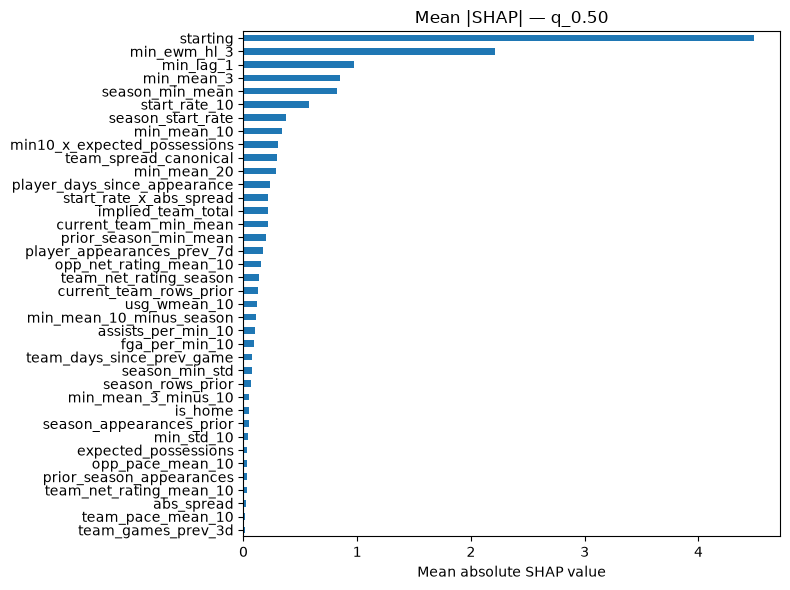

In [34]:
model = models_last["q_0.50"]
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_last)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=MIN_FEATURES).sort_values(ascending=True)

ax = feat_imp.plot(kind="barh", figsize=(8, 6))
ax.set_title("Mean |SHAP| — q_0.50")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()


In [35]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from scipy import stats as sp_stats

result = permutation_importance(
    models_last["q_0.50"],
    X_val_last,
    y_val_last,
    n_repeats=30,
    random_state=42,
    scoring=make_scorer(pinball_50),
)

pi_df = (
    pd.DataFrame({
        "feature": X_val_last.columns,
        "importance": result.importances_mean,
        "std": result.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
pi_df.index += 1
pi_df["importance"] = pi_df["importance"].round(5)
pi_df["std"] = pi_df["std"].round(5)
pi_df["p_value"] = sp_stats.ttest_1samp(result.importances, 0.0, axis=1).pvalue.round(4)
pi_df["significant"] = pi_df["p_value"] < 0.05

print("Permutation importance (val set) — higher = more important, significant = p<0.05")
print(pi_df.to_string())


Permutation importance (val set) — higher = more important, significant = p<0.05
                         feature  importance      std  p_value  significant
1                       starting     1.13218  0.01843   0.0000         True
2                   min_ewm_hl_3     0.48071  0.00869   0.0000         True
3                      min_lag_1     0.13835  0.00489   0.0000         True
4                season_min_mean     0.11017  0.00366   0.0000         True
5                     min_mean_3     0.09902  0.00439   0.0000         True
6                  start_rate_10     0.07963  0.00339   0.0000         True
7              season_start_rate     0.03149  0.00214   0.0000         True
8          team_spread_canonical     0.02490  0.00229   0.0000         True
9   player_days_since_appearance     0.01922  0.00206   0.0000         True
10                   min_mean_10     0.01749  0.00132   0.0000         True
11                   min_mean_20     0.01635  0.00130   0.0000         True
12     

In [36]:
train_mask_last = last_fold["train_mask"]
val_mask_last = last_fold["val_mask"]
X_tr_last = X[train_mask_last]
X_va_last = X[val_mask_last]
y_tr_last = y[train_mask_last]
y_va_last = y[val_mask_last]

ablation_df = run_feature_ablation(
    MIN_FEATURES, X_tr_last, y_tr_last, X_va_last, y_va_last,
    xgb_params=XGB_PARAMS,
)


Baseline pinball q50 (all features): 2.2516
                         feature  ablated_pinball  delta_pinball
1                       starting           2.3628         0.1113
2                      min_lag_1           2.2639         0.0123
3   player_days_since_appearance           2.2554         0.0038
4                 season_min_std           2.2542         0.0027
5         opp_net_rating_mean_10           2.2530         0.0015
6          current_team_min_mean           2.2527         0.0011
7        start_rate_x_abs_spread           2.2522         0.0007
8            min_mean_3_minus_10           2.2522         0.0007
9              season_start_rate           2.2521         0.0006
10                   min_mean_10           2.2520         0.0004
11         prior_season_min_mean           2.2518         0.0002
12  min10_x_expected_possessions           2.2517         0.0002
13      season_appearances_prior           2.2516         0.0000
14               season_min_mean           2.2

In [37]:
from scipy import stats

model = models_last["q_0.50"]
_shap_expl = shap.TreeExplainer(model, model_output="raw")
_shap_vals = _shap_expl(X_val_last)
_mean_abs_shap = np.abs(_shap_vals.values).mean(axis=0)

shap_table = pd.DataFrame({
    "feature": X_val_last.columns,
    "mean_abs_shap": _mean_abs_shap,
}).assign(shap_rank=lambda d: d["mean_abs_shap"].rank(method="min", ascending=False).astype(int))

perm_table = (
    pi_df.sort_values("importance", ascending=False)
    .reset_index(drop=True)
    .rename(columns={"importance": "perm_importance", "std": "perm_importance_std"})
)
perm_table["perm_rank"] = np.arange(1, len(perm_table) + 1)
perm_table = perm_table[["feature", "perm_rank", "perm_importance", "perm_importance_std"]]

perm_pv = pd.DataFrame({
    "feature": X_val_last.columns,
    "perm_pvalue": stats.ttest_1samp(result.importances, 0.0, axis=1, nan_policy="omit").pvalue,
})

abla = ablation_df[["feature", "delta_pinball"]].rename(columns={"delta_pinball": "ablation_delta"})

feature_audit = (
    pd.DataFrame({"feature": MIN_FEATURES})
    .merge(shap_table, on="feature", how="left")
    .merge(perm_table, on="feature", how="left")
    .merge(perm_pv, on="feature", how="left")
    .merge(abla, on="feature", how="left")
)

_ms = feature_audit["mean_abs_shap"].astype(float)
_mp = feature_audit["perm_importance"].astype(float)
_max_shap = _ms.fillna(0).max()
_max_perm = _mp.fillna(0).max()
feature_audit["shap_norm"] = np.where(_max_shap > 0, _ms.fillna(0) / _max_shap, 0.0)
feature_audit["perm_norm"] = np.where(_max_perm > 0, _mp.fillna(0) / _max_perm, 0.0)
feature_audit["consensus"] = (feature_audit["shap_norm"] + feature_audit["perm_norm"]) / 2
feature_audit = feature_audit.sort_values("consensus", ascending=False).reset_index(drop=True)
feature_audit.index += 1
feature_audit["keep"] = (feature_audit["perm_pvalue"] < 0.05) & (feature_audit["ablation_delta"] > 0)

print(feature_audit.to_string())


                         feature  mean_abs_shap  shap_rank  perm_rank  perm_importance  perm_importance_std   perm_pvalue  ablation_delta  shap_norm  perm_norm  consensus   keep
1                       starting       4.492534          1          1          1.13218              0.01843  1.998701e-53          0.1113   1.000000   1.000000   1.000000   True
2                   min_ewm_hl_3       2.210297          2          2          0.48071              0.00869  4.133271e-52         -0.0011   0.491993   0.424588   0.458291  False
3                      min_lag_1       0.972676          3          3          0.13835              0.00489  1.151533e-43          0.0123   0.216510   0.122198   0.169354   True
4                season_min_mean       0.823236          5          4          0.11017              0.00366  1.916848e-44         -0.0001   0.183245   0.097308   0.140277  False
5                     min_mean_3       0.849193          4          5          0.09902              0.00439  8

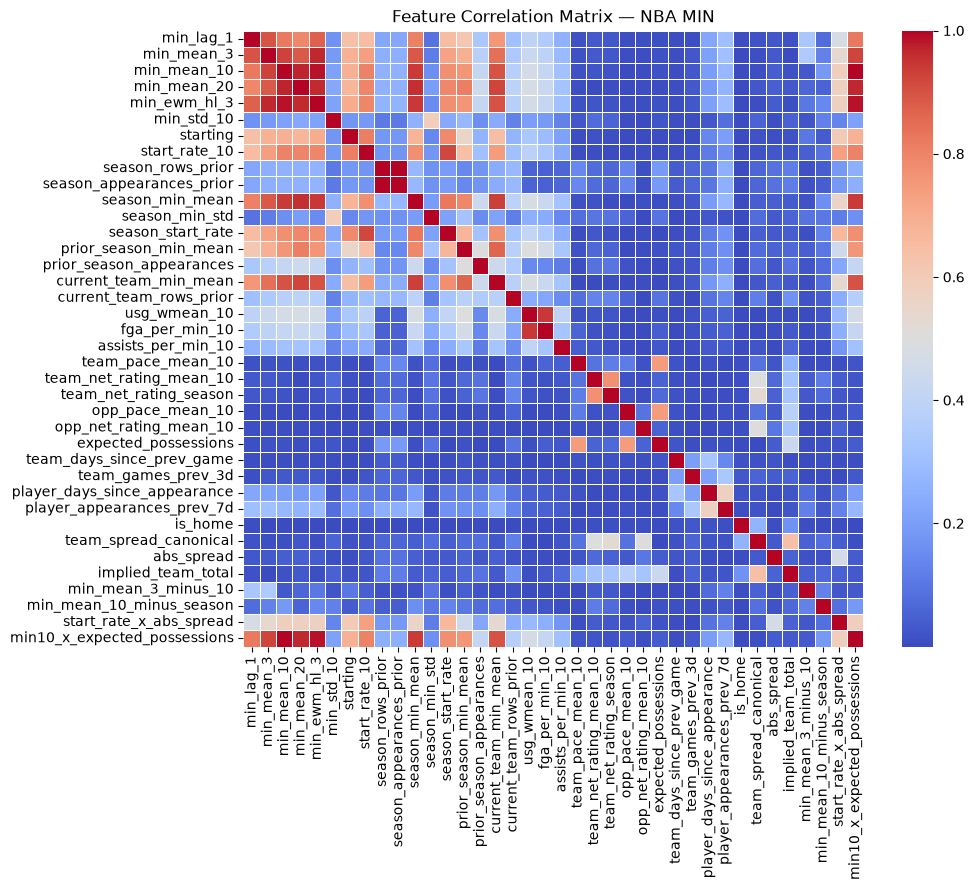

--- High Correlation Report (Threshold > 0.95) ---
season_appearances_prior <-> season_rows_prior: 1.0000
min10_x_expected_possessions <-> min_mean_10: 0.9986
min_ewm_hl_3 <-> min_mean_10: 0.9874
min10_x_expected_possessions <-> min_ewm_hl_3: 0.9861
min_mean_20 <-> min_mean_10: 0.9694
min10_x_expected_possessions <-> min_mean_20: 0.9684
min_ewm_hl_3 <-> min_mean_3: 0.9659
min_ewm_hl_3 <-> min_mean_20: 0.9616
season_min_mean <-> min_mean_20: 0.9542


['min_mean_20',
 'min_ewm_hl_3',
 'season_appearances_prior',
 'season_min_mean',
 'min10_x_expected_possessions']

In [38]:
correlated_features = analyze_correlations(
    df, MIN_FEATURES, title="Feature Correlation Matrix — NBA MIN"
)
correlated_features


In [39]:
holdout = evaluate_holdout(
    ppm_df,
    ppm_holdout,
    features=MIN_FEATURES,
    target_col=TARGET_COL,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    wf_results=wf_results,
    quantiles=QUANTILES,
    fold_label=f"{HOLDOUT_SEASON} Blind Holdout",
)
models_ho = holdout["models_ho"]
preds_ho = holdout["preds_ho"]
ho_metrics = holdout["ho_metrics"]
X_ho = holdout["X_ho"]
y_ho = holdout["y_ho"]

ho_pinball, ho_coverage = score_predictions(
    y_ho, preds_ho, f"{HOLDOUT_SEASON} holdout"
)
display(ho_pinball.round(4))
display(ho_coverage.round(4))


── 2025-26 Blind Holdout ─────────────────────────────────────────────────
  Train pool: 90% rows for fit, remainder for early-stopping only; predict holdout (never in eval_set).

2025-26 Blind Holdout
  n=26648
  pinball  | q0.05=0.610  q0.10=1.014  q0.20=1.597  q0.30=1.967  q0.40=2.179  q0.50=2.250  q0.60=2.185  q0.70=1.974  q0.80=1.602  q0.90=1.020  q0.95=0.609
  coverage | 80%=79.9% (target 80%)  90%=89.6% (target 90%)
  Starters   | n=12300 | pinball q50: 2.073 | 80% coverage: 80.9%
  Bench      | n=14348 | pinball q50: 2.403 | 80% coverage: 79.0%
  <15 min    | n= 6548 | pinball q50: 2.555 | 80% coverage: 74.7%
  15-24 min  | n= 7365 | pinball q50: 2.283 | 80% coverage: 83.7%
  24-31 min  | n= 6682 | pinball q50: 2.079 | 80% coverage: 84.4%
  31+ min    | n= 6053 | pinball q50: 2.070 | 80% coverage: 75.8%

───────────────────────────────────────────────────────
  Walk-forward pinball q50 (mean) : 2.254
  Holdout pinball q50             : 2.250
  Pinball gap                     : 

,split,quantile,pinball
0,2025-26 holdout,0.05,0.6099
1,2025-26 holdout,0.10,1.0138
2,2025-26 holdout,0.20,1.5966
3,2025-26 holdout,0.30,1.9668
4,2025-26 holdout,0.40,2.1786
5,2025-26 holdout,0.50,2.2503
6,2025-26 holdout,0.60,2.1847
7,2025-26 holdout,0.70,1.9743
8,2025-26 holdout,0.80,1.6017
9,2025-26 holdout,0.90,1.0198


,split,interval,coverage,target
0,2025-26 holdout,80%,0.7987,0.8


In [43]:
y_true = np.asarray(y_ho, dtype=float)
calibration_rows = []
for key, pred in preds_ho.items():
    alpha = float(str(key).split("_", 1)[1])
    pred = np.asarray(pred, dtype=float)
    empirical = float(np.mean(y_true <= pred))
    calibration_rows.append({
        "quantile": alpha,
        "target": alpha,
        "empirical": empirical,
        "delta": empirical - alpha,
    })
calibration = (
    pd.DataFrame(calibration_rows)
    .sort_values("quantile")
    .reset_index(drop=True)
)

sharpness_rows = []
for low, high, nominal in ((0.10, 0.90, 0.80), (0.05, 0.95, 0.90)):
    low_key, high_key = f"q_{low:.2f}", f"q_{high:.2f}"
    if low_key not in preds_ho or high_key not in preds_ho:
        continue
    width = (
        np.asarray(preds_ho[high_key], dtype=float)
        - np.asarray(preds_ho[low_key], dtype=float)
    )
    sharpness_rows.append({
        "interval": f"{nominal:.0%}",
        "coverage": interval_coverage(y_true, preds_ho[low_key], preds_ho[high_key]),
        "target": nominal,
        "mean_width": float(np.mean(width)),
        "median_width": float(np.median(width)),
    })
sharpness = pd.DataFrame(sharpness_rows)

print(f"{HOLDOUT_SEASON} holdout — empirical quantile calibration")
display(calibration.round(4))
print(f"{HOLDOUT_SEASON} holdout — interval sharpness (minutes)")
display(sharpness.round(4))


2025-26 holdout — empirical quantile calibration


,quantile,target,empirical,delta
0,0.05,0.05,0.0526,0.0026
1,0.10,0.10,0.1023,0.0023
2,0.20,0.20,0.2005,0.0005
3,0.30,0.30,0.2998,-0.0002
4,0.40,0.40,0.4031,0.0031
5,0.50,0.50,0.5046,0.0046
6,0.60,0.60,0.6073,0.0073
7,0.70,0.70,0.7063,0.0063
8,0.80,0.80,0.8060,0.0060
9,0.90,0.90,0.9010,0.0010


2025-26 holdout — interval sharpness (minutes)


,interval,coverage,target,mean_width,median_width
0,80%,0.7987,0.8,14.238,13.9647
1,90%,0.8956,0.9,18.417,18.2098


In [44]:
quantile_keys = sorted(
    preds_ho,
    key=lambda key: float(str(key).split("_", 1)[1]),
)
grid = np.column_stack([
    np.asarray(preds_ho[key], dtype=float) for key in quantile_keys
])
crossed = np.any(np.diff(grid, axis=1) < 0, axis=1)
n_rows = int(len(crossed))
n_crossed = int(crossed.sum())
print(
    f"{HOLDOUT_SEASON} holdout quantile crossing: "
    f"{n_crossed:,} / {n_rows:,} rows ({n_crossed / n_rows:.1%})"
)

pair_rows = []
for left, right in zip(quantile_keys, quantile_keys[1:]):
    pair_rate = float(np.mean(
        np.asarray(preds_ho[left], dtype=float)
        > np.asarray(preds_ho[right], dtype=float)
    ))
    pair_rows.append({
        "lower": left,
        "upper": right,
        "crossing_rate": pair_rate,
    })
crossing_pairs = pd.DataFrame(pair_rows)
display(crossing_pairs.round(4))


2025-26 holdout quantile crossing: 145 / 26,648 rows (0.5%)


,lower,upper,crossing_rate
0,q_0.05,q_0.10,0.0013
1,q_0.10,q_0.20,0.0015
2,q_0.20,q_0.30,0.0008
3,q_0.30,q_0.40,0.0005
4,q_0.40,q_0.50,0.0007
5,q_0.50,q_0.60,0.0004
6,q_0.60,q_0.70,0.0002
7,q_0.70,q_0.80,0.0003
8,q_0.80,q_0.90,0.0000
9,q_0.90,q_0.95,0.0001


In [45]:
predicted = np.asarray(preds_ho["q_0.50"], dtype=float)
y_true = np.asarray(y_ho, dtype=float)
low_80 = np.asarray(preds_ho["q_0.10"], dtype=float)
high_80 = np.asarray(preds_ho["q_0.90"], dtype=float)
low_90 = np.asarray(preds_ho["q_0.05"], dtype=float)
high_90 = np.asarray(preds_ho["q_0.95"], dtype=float)
width_80 = high_80 - low_80
width_90 = high_90 - low_90

tier_rows = []
for name, fn in MIN_TIERS.items():
    mask = np.asarray(fn(predicted), dtype=bool)
    n = int(mask.sum())
    if n == 0:
        continue
    tier_rows.append({
        "tier": name,
        "n": n,
        "share": n / len(predicted),
        "pinball_q50": pinball_loss(y_true[mask], predicted[mask], 0.50),
        "empirical_q50": float(np.mean(y_true[mask] <= predicted[mask])),
        "coverage_80": interval_coverage(y_true[mask], low_80[mask], high_80[mask]),
        "coverage_90": interval_coverage(y_true[mask], low_90[mask], high_90[mask]),
        "mean_width_80": float(np.mean(width_80[mask])),
        "mean_width_90": float(np.mean(width_90[mask])),
    })
tier_report = pd.DataFrame(tier_rows)
print(f"{HOLDOUT_SEASON} holdout — minute tiers by predicted q50")
display(tier_report.round(4))


2025-26 holdout — minute tiers by predicted q50


,tier,n,share,pinball_q50,empirical_q50,coverage_80,coverage_90,mean_width_80,mean_width_90
0,<15 min,6458,0.2423,2.5643,0.4969,0.7775,0.8843,15.7651,19.9265
1,15-24 min,7222,0.2710,2.3286,0.4884,0.8023,0.8945,15.0278,19.6069
2,24-31 min,7290,0.2736,2.1597,0.5133,0.8081,0.9021,13.9851,18.0310
3,31+ min,5678,0.2131,1.9097,0.5229,0.8064,0.9014,11.8210,15.6821


In [46]:
N_BOOT = 2_000
SEED = 42

y = np.asarray(y_ho, dtype=float)
predictors = {
    "model": np.asarray(preds_ho["q_0.50"], dtype=float),
    "season_average": ppm_holdout["season_min_mean"].to_numpy(dtype=float),
    "last_game": ppm_holdout["min_lag_1"].to_numpy(dtype=float),
    "ewma": ppm_holdout["min_ewm_hl_3"].to_numpy(dtype=float),
}
dates = ppm_holdout["game_date"].to_numpy()
finite = np.isfinite(y)
for pred in predictors.values():
    finite &= np.isfinite(pred)
n_dropped = int((~finite).sum())

y = y[finite]
dates = dates[finite]
predictors = {name: pred[finite] for name, pred in predictors.items()}
codes, _unique_dates = pd.factorize(dates, sort=False)
n_clusters = int(codes.max()) + 1
abs_err = {name: np.abs(y - pred) for name, pred in predictors.items()}
cluster_n = np.bincount(codes).astype(float)
cluster_sum = {
    name: np.bincount(codes, weights=err) for name, err in abs_err.items()
}

rng = np.random.default_rng(SEED)
draws = rng.integers(0, n_clusters, size=(N_BOOT, n_clusters))
weights = np.zeros((N_BOOT, n_clusters), dtype=np.int32)
np.add.at(
    weights,
    (np.repeat(np.arange(N_BOOT), n_clusters), draws.ravel()),
    1,
)
denom = weights @ cluster_n
boot_mae = {
    name: (weights @ cluster_sum[name]) / denom for name in predictors
}
point = {name: float(err.mean()) for name, err in abs_err.items()}

labels = {
    "model": "Model (q50)",
    "season_average": "Season average",
    "last_game": "Last-game minutes",
    "ewma": "EWMA (halflife 3)",
}
order = ["model", "season_average", "last_game", "ewma"]
mae_table = pd.DataFrame([
    {
        "predictor": labels[name],
        "mae": point[name],
        "ci_low": float(np.quantile(boot_mae[name], 0.025)),
        "ci_high": float(np.quantile(boot_mae[name], 0.975)),
    }
    for name in order
])
delta_table = pd.DataFrame([
    {
        "comparison": f"model − {labels[name]}",
        "delta_mae": point["model"] - point[name],
        "ci_low": float(np.quantile(boot_mae["model"] - boot_mae[name], 0.025)),
        "ci_high": float(np.quantile(boot_mae["model"] - boot_mae[name], 0.975)),
    }
    for name in order[1:]
])

print(
    f"{HOLDOUT_SEASON} holdout MAE \u2014 paired bootstrap clustered by game date\n"
    f"  {N_BOOT:,} resamples | {n_clusters:,} dates | {len(y):,} rows"
    f" | dropped {n_dropped:,} rows with a missing baseline"
)
display(mae_table.round(3))
print("Paired difference (negative means the model has lower MAE)")
display(delta_table.round(3))


2025-26 holdout MAE — paired bootstrap clustered by game date
  2,000 resamples | 162 dates | 26,066 rows | dropped 582 rows with a missing baseline


,predictor,mae,ci_low,ci_high
0,Model (q50),4.480,4.409,4.565
1,Season average,5.298,5.168,5.456
2,Last-game minutes,5.766,5.663,5.871
3,EWMA (halflife 3),4.933,4.834,5.061


Paired difference (negative means the model has lower MAE)


,comparison,delta_mae,ci_low,ci_high
0,model − Season average,-0.818,-0.909,-0.733
1,model − Last-game minutes,-1.286,-1.348,-1.226
2,model − EWMA (halflife 3),-0.453,-0.510,-0.404


### Frozen minutes acceptance report

Identical holdout rows for the quantile model against last-game minutes, the season-to-date average, and EWMA. Distribution scores, per-quantile calibration, and pregame slices follow. Walk-forward fold MAEs use the saved q50 pinball.

In [47]:
N_BOOT = 2_000
SEED = 42
WIS_INTERVALS = (
    (0.80, "q_0.40", "q_0.60"),
    (0.60, "q_0.30", "q_0.70"),
    (0.40, "q_0.20", "q_0.80"),
    (0.20, "q_0.10", "q_0.90"),
    (0.10, "q_0.05", "q_0.95"),
)

y_all = np.asarray(y_ho, dtype=float)
quantiles = {key: np.asarray(pred, dtype=float) for key, pred in preds_ho.items()}
alpha_of = {key: float(str(key).split("_", 1)[1]) for key in quantiles}
ordered_keys = sorted(quantiles, key=alpha_of.get)
model = quantiles["q_0.50"]
baselines = {
    "Last-game minutes": ppm_holdout["min_lag_1"].to_numpy(dtype=float),
    "Season-to-date average": ppm_holdout["season_min_mean"].to_numpy(dtype=float),
    "EWMA minutes": ppm_holdout["min_ewm_hl_3"].to_numpy(dtype=float),
}
paired = np.isfinite(y_all) & np.isfinite(model)
for pred in baselines.values():
    paired &= np.isfinite(pred)

def point_row(name, y, pred):
    error = y - pred
    absolute = np.abs(error)
    return {
        "model": name,
        "mae": float(absolute.mean()),
        "median_ae": float(np.median(absolute)),
        "mean_bias": float(error.mean()),
    }

def interval_score(y, lower, upper, alpha):
    width = upper - lower
    below = y < lower
    above = y > upper
    return (
        width
        + (2.0 / alpha) * (lower - y) * below
        + (2.0 / alpha) * (y - upper) * above
    )

def wis_values(y, qmap):
    present = [
        (alpha, qmap[low], qmap[high])
        for alpha, low, high in WIS_INTERVALS
        if low in qmap and high in qmap
    ]
    total = 0.5 * np.abs(y - qmap["q_0.50"])
    for alpha, lower, upper in present:
        total = total + (alpha / 2.0) * interval_score(y, lower, upper, alpha)
    return total / (len(present) + 0.5)

def clustered_mae_bootstrap(y, predictors, dates, n_boot, seed):
    codes, _ = pd.factorize(dates, sort=False)
    n_clusters = int(codes.max()) + 1
    cluster_n = np.bincount(codes).astype(float)
    cluster_sum = {
        name: np.bincount(codes, weights=np.abs(y - pred))
        for name, pred in predictors.items()
    }
    rng = np.random.default_rng(seed)
    draws = rng.integers(0, n_clusters, size=(n_boot, n_clusters))
    weights = np.zeros((n_boot, n_clusters), dtype=np.int32)
    np.add.at(
        weights,
        (np.repeat(np.arange(n_boot), n_clusters), draws.ravel()),
        1,
    )
    denom = weights @ cluster_n
    return {name: (weights @ total) / denom for name, total in cluster_sum.items()}

y_paired = y_all[paired]
paired_preds = {"Quantile XGBoost q50": model[paired]}
paired_preds.update({name: pred[paired] for name, pred in baselines.items()})
dates_paired = pd.to_datetime(ppm_holdout["game_date"]).to_numpy()[paired]
boot_mae = clustered_mae_bootstrap(
    y_paired, paired_preds, dates_paired, N_BOOT, SEED
)

point_order = [
    "Last-game minutes",
    "Season-to-date average",
    "EWMA minutes",
    "Quantile XGBoost q50",
]
point_table = pd.DataFrame([
    point_row(name, y_paired, paired_preds[name]) for name in point_order
])
best_name = min(baselines, key=lambda name: point_table.loc[
    point_table["model"] == name, "mae"
].iloc[0])
model_boot = boot_mae["Quantile XGBoost q50"]
delta_table = pd.DataFrame([
    {
        "comparison": f"q50 − {name}",
        "delta_mae": float(
            point_table.loc[point_table["model"] == "Quantile XGBoost q50", "mae"].iloc[0]
            - point_table.loc[point_table["model"] == name, "mae"].iloc[0]
        ),
        "ci_low": float(np.quantile(model_boot - boot_mae[name], 0.025)),
        "ci_high": float(np.quantile(model_boot - boot_mae[name], 0.975)),
    }
    for name in point_order[:-1]
])

fold_rows = []
for fold in wf_results:
    part = ppm_df.loc[fold["val_mask"]]
    y_fold = part[TARGET_COL].to_numpy(dtype=float)
    fold_row = {
        "fold": fold["fold"],
        "n": int(len(part)),
        "model_mae": 2.0 * float(fold["pinball"]),
    }
    for name, column in (
        ("last_game", "min_lag_1"),
        ("season_average", "season_min_mean"),
        ("ewma", "min_ewm_hl_3"),
    ):
        pred = part[column].to_numpy(dtype=float)
        ok = np.isfinite(y_fold) & np.isfinite(pred)
        fold_row[name] = float(np.mean(np.abs(y_fold[ok] - pred[ok])))
    fold_row["best_baseline"] = min(
        fold_row["last_game"], fold_row["season_average"], fold_row["ewma"]
    )
    fold_row["model_minus_best"] = fold_row["model_mae"] - fold_row["best_baseline"]
    fold_rows.append(fold_row)
fold_table = pd.DataFrame(fold_rows)

print("1. Point accuracy versus baselines")
print(
    f"Identical holdout rows: {int(paired.sum()):,}  |  "
    f"dropped {int((~paired).sum()):,} with a missing baseline  |  "
    f"{N_BOOT:,} date-clustered resamples"
)
print(
    "Mean bias is actual minus predicted. "
    f"q50 pinball {pinball_loss(y_paired, paired_preds['Quantile XGBoost q50'], 0.50):.4f} "
    "equals half the q50 MAE."
)
display(point_table.round(3))
print("Paired MAE difference, clustered by game date. Negative means q50 is lower.")
display(delta_table.round(3))
print(
    "Walk-forward model MAE is 2 × q50 pinball on every validation row. "
    "Baseline MAE drops rows with no prior."
)
display(fold_table.round(3))

print("\n2. Distribution quality")
width_80 = quantiles["q_0.90"] - quantiles["q_0.10"]
width_90 = quantiles["q_0.95"] - quantiles["q_0.05"]
grid = np.column_stack([quantiles[key] for key in ordered_keys])
crossed = np.any(np.diff(grid, axis=1) < 0, axis=1)
distribution = pd.DataFrame([
    {
        "cov_80": interval_coverage(y_all, quantiles["q_0.10"], quantiles["q_0.90"]),
        "width_80_mean": float(width_80.mean()),
        "width_80_median": float(np.median(width_80)),
        "cov_90": interval_coverage(y_all, quantiles["q_0.05"], quantiles["q_0.95"]),
        "width_90_mean": float(width_90.mean()),
        "width_90_median": float(np.median(width_90)),
        "wis": float(np.mean(wis_values(y_all, quantiles))),
        "quantile_crossing": float(crossed.mean()),
    }
])
display(distribution.round(4))
print(
    f"Best baseline MAE {point_table.loc[point_table['model'] == best_name, 'mae'].iloc[0]:.3f} "
    f"({best_name}) is that point forecast's CRPS. Model WIS is the distribution score."
)

print("\n3. Calibration of every quantile")
calibration = pd.DataFrame([
    {
        "quantile": f"q{alpha_of[key] * 100:02.0f}",
        "expected": alpha_of[key],
        "observed": float(np.mean(y_all <= quantiles[key])),
        "difference": float(np.mean(y_all <= quantiles[key]) - alpha_of[key]),
    }
    for key in ordered_keys
])
display(calibration.round(4))

def subgroup_row(name, mask):
    mask = np.asarray(mask, dtype=bool) & np.isfinite(y_all) & np.isfinite(model)
    n = int(mask.sum())
    if n == 0:
        return None
    y = y_all[mask]
    qmap = {key: values[mask] for key, values in quantiles.items()}
    error = y - qmap["q_0.50"]
    return {
        "group": name,
        "n": n,
        "mae": float(np.mean(np.abs(error))),
        "bias": float(np.mean(error)),
        "wis": float(np.mean(wis_values(y, qmap))),
        "cov_80": interval_coverage(y, qmap["q_0.10"], qmap["q_0.90"]),
        "width_80_mean": float(np.mean(qmap["q_0.90"] - qmap["q_0.10"])),
        "width_80_median": float(np.median(qmap["q_0.90"] - qmap["q_0.10"])),
        "cov_90": interval_coverage(y, qmap["q_0.05"], qmap["q_0.95"]),
        "width_90_mean": float(np.mean(qmap["q_0.95"] - qmap["q_0.05"])),
        "width_90_median": float(np.median(qmap["q_0.95"] - qmap["q_0.05"])),
    }

print("\n4. Pregame-defined subgroups")
starting = ppm_holdout["starting"].to_numpy()
months = pd.to_datetime(ppm_holdout["game_date"]).dt.to_period("M").astype(str)
subgroup_rows = [
    subgroup_row("Confirmed starter", starting == 1),
    subgroup_row("Bench", starting == 0),
]
for name, fn in MIN_TIERS.items():
    subgroup_rows.append(subgroup_row(f"Predicted q50 {name}", fn(model)))
for month in sorted(months.unique()):
    subgroup_rows.append(subgroup_row(str(month), months.to_numpy() == month))
subgroup_table = pd.DataFrame([row for row in subgroup_rows if row is not None])
display(subgroup_table.round(3))

print("\n5. Tail failures")
absolute_error = np.abs(y_all - model)
tail_table = pd.DataFrame([
    {
        "threshold": f">{cutoff:g} min",
        "rate": float(np.mean(absolute_error > cutoff)),
        "n": int(np.sum(absolute_error > cutoff)),
    }
    for cutoff in (5, 10, 15)
])
display(tail_table.round(4))

q50_rate = float(calibration.loc[calibration["quantile"] == "q50", "observed"].iloc[0])
max_gap = float(calibration["difference"].abs().max())
best_delta = delta_table.loc[delta_table["comparison"] == f"q50 − {best_name}"].iloc[0]
model_wis = float(distribution["wis"].iloc[0])
best_mae = float(point_table.loc[point_table["model"] == best_name, "mae"].iloc[0])
print("\nChecks from this frame")
print(f"  q50 observed rate {q50_rate:.1%}  (target about 48–52%)")
print(f"  largest |quantile gap| {max_gap:.1%}")
print(
    f"  q50 vs {best_name}: delta MAE {best_delta['delta_mae']:+.3f} "
    f"[{best_delta['ci_low']:+.3f}, {best_delta['ci_high']:+.3f}]"
)
print(f"  model WIS {model_wis:.3f} vs best baseline CRPS/MAE {best_mae:.3f}")
print(
    "  walk-forward folds with model MAE below the best baseline: "
    f"{int((fold_table['model_minus_best'] < 0).sum())} / {len(fold_table)}"
)
print(f"  raw quantile crossing {float(crossed.mean()):.2%} of rows")


1. Point accuracy versus baselines
Identical holdout rows: 26,066  |  dropped 582 with a missing baseline  |  2,000 date-clustered resamples
Mean bias is actual minus predicted. q50 pinball 2.2400 equals half the q50 MAE.


,model,mae,median_ae,mean_bias
0,Last-game minutes,5.766,4.417,0.083
1,Season-to-date average,5.298,4.143,0.624
2,EWMA minutes,4.933,3.887,0.099
3,Quantile XGBoost q50,4.480,3.505,-0.049


Paired MAE difference, clustered by game date. Negative means q50 is lower.


,comparison,delta_mae,ci_low,ci_high
0,q50 − Last-game minutes,-1.286,-1.348,-1.226
1,q50 − Season-to-date average,-0.818,-0.909,-0.733
2,q50 − EWMA minutes,-0.453,-0.510,-0.404


Walk-forward model MAE is 2 × q50 pinball on every validation row. Baseline MAE drops rows with no prior.


...


4. Pregame-defined subgroups


,group,n,mae,bias,wis,cov_80,width_80_mean,width_80_median,cov_90,width_90_mean,width_90_median
0,Confirmed starter,12300,4.145,-0.613,2.876,0.809,13.184,12.969,0.902,17.178,16.823
1,Bench,14348,4.805,0.489,3.277,0.790,15.141,15.102,0.890,19.479,19.469
2,Predicted q50 <15 min,6458,5.129,1.031,3.464,0.777,15.765,15.948,0.884,19.927,20.038
3,Predicted q50 15-24 min,7222,4.657,0.108,3.196,0.802,15.028,14.855,0.894,19.607,19.473
4,Predicted q50 24-31 min,7290,4.319,-0.434,2.981,0.808,13.985,13.743,0.902,18.031,17.728
5,Predicted q50 31+ min,5678,3.819,-0.845,2.680,0.806,11.821,11.788,0.901,15.682,15.463
6,2025-10,1791,4.551,0.078,3.158,0.796,14.416,14.087,0.892,18.679,18.317
7,2025-11,4784,4.388,0.087,3.019,0.806,13.923,13.629,0.898,17.963,17.711
8,2025-12,4265,4.455,-0.131,3.067,0.796,14.135,13.841,0.891,18.200,17.976
9,2026-01,4987,4.262,-0.147,2.936,0.818,14.107,13.859,0.909,18.260,18.110



5. Tail failures


,threshold,rate,n
0,>5 min,0.3470,9246
1,>10 min,0.0880,2345
2,>15 min,0.0215,573



Checks from this frame
  q50 observed rate 50.5%  (target about 48–52%)
  largest |quantile gap| 0.7%
  q50 vs EWMA minutes: delta MAE -0.453 [-0.510, -0.404]
  model WIS 3.092 vs best baseline CRPS/MAE 4.933
  walk-forward folds with model MAE below the best baseline: 4 / 4
  raw quantile crossing 0.54% of rows


### Follow-ups before freezing

April versus the rest of the regular season, starter and bench median calibration, monotone quantile rearrangement, and the cold-start rows.

In [48]:
import importlib

import models.shared.artifacts as artifact_mod

importlib.reload(artifact_mod)
from models.shared.artifacts import monotonize_quantiles

dates = pd.to_datetime(ppm_holdout["game_date"])
y_all = np.asarray(y_ho, dtype=float)
raw_q = {key: np.asarray(pred, dtype=float) for key, pred in preds_ho.items()}
model = raw_q["q_0.50"]

def slice_score(name, mask, qmap):
    mask = np.asarray(mask, dtype=bool)
    n = int(mask.sum())
    if n == 0:
        return {"slice": name, "n": 0}
    y = y_all[mask]
    qmap = {key: values[mask] for key, values in qmap.items()}
    error = y - qmap["q_0.50"]
    return {
        "slice": name,
        "n": n,
        "mae": float(np.mean(np.abs(error))),
        "bias": float(np.mean(error)),
        "p_actual_le_q50": float(np.mean(y <= qmap["q_0.50"])),
        "cov_80": interval_coverage(y, qmap["q_0.10"], qmap["q_0.90"]),
        "mean_width_80": float(np.mean(qmap["q_0.90"] - qmap["q_0.10"])),
        "wis": float(np.mean(wis_values(y, qmap))),
    }

print("1. April is late regular season, not the postseason")
holdout_season = df.loc[df["season_year"].astype("string").eq(str(HOLDOUT_SEASON))]
print(holdout_season["season_type"].astype("string").value_counts(dropna=False).to_string())
print(
    f"Holdout dates {dates.min().date()} \u2192 {dates.max().date()}. "
    "The silver store only has regular_season gamelogs, so playoff games are not in this test."
)
blocks = {
    "October\u2013February": dates < "2026-03-01",
    "March 1\u201314": (dates >= "2026-03-01") & (dates < "2026-03-15"),
    "March 15\u201331": (dates >= "2026-03-15") & (dates < "2026-04-01"),
    "April regular season": dates >= "2026-04-01",
}
calendar = pd.DataFrame([slice_score(name, mask, raw_q) for name, mask in blocks.items()])
display(calendar.round(3))
print(
    "Limitation: April's higher MAE and lower 80% coverage is the last two weeks of the "
    "regular season. It is not a postseason effect, and the model has not been tested on playoff games."
)

print("\n2. Starter and bench mean bias versus median calibration")
starting = ppm_holdout["starting"].to_numpy()
role = pd.DataFrame([
    slice_score("Confirmed starter", starting == 1, raw_q),
    slice_score("Bench", starting == 0, raw_q),
])
display(role.round(3))
for _, row in role.iterrows():
    if row["n"] == 0:
        continue
    gap = row["p_actual_le_q50"] - 0.50
    if abs(gap) <= 0.02:
        reading = "q50 is near 50%, so the mean bias is skew around a calibrated median"
    elif gap > 0:
        reading = "q50 is too high: actuals fall under the median more often than 50%"
    else:
        reading = "q50 is too low: actuals fall under the median less often than 50%"
    print(
        f"  {row['slice']}: bias {row['bias']:+.2f} min, "
        f"P(actual <= q50) {row['p_actual_le_q50']:.1%}. {reading}."
    )

print("\n3. Monotone rearrangement")
ordered_keys = sorted(raw_q, key=lambda key: float(str(key).split("_", 1)[1]))
grid = np.column_stack([raw_q[key] for key in ordered_keys])
crossed = np.any(np.diff(grid, axis=1) < 0, axis=1)
preds_ho_mono = monotonize_quantiles(raw_q)
mono_grid = np.column_stack([preds_ho_mono[key] for key in ordered_keys])
shift = pd.DataFrame([
    {
        "quantile": key,
        "mean_abs_shift": float(np.mean(np.abs(preds_ho_mono[key] - raw_q[key]))),
        "share_changed": float(np.mean(preds_ho_mono[key] != raw_q[key])),
    }
    for key in ordered_keys
])
print(
    f"Crossing before {crossed.mean():.2%} of rows; "
    f"after rearrangement {np.any(np.diff(mono_grid, axis=1) < 0, axis=1).mean():.2%}."
)
display(shift.round(4))
print("Simulate from preds_ho_mono. The saved trees stay raw; sort each row after predict.")

print("\n4. Cold-start and missing-baseline rows")
lag = ppm_holdout["min_lag_1"].to_numpy(dtype=float)
season_avg = ppm_holdout["season_min_mean"].to_numpy(dtype=float)
ewma = ppm_holdout["min_ewm_hl_3"].to_numpy(dtype=float)
cold = ~np.isfinite(lag)
season_opener = np.isfinite(lag) & ~np.isfinite(season_avg)
missing_any = cold | season_opener | ~np.isfinite(ewma)
print(
    f"Missing any baseline: {int(missing_any.sum()):,} | "
    f"no prior game (min_lag_1 missing): {int(cold.sum()):,} | "
    f"season opener with history: {int(season_opener.sum()):,}"
)

role_quantiles = {}
for role_value, role_name in ((1, "starter"), (0, "bench")):
    history = ppm_df.loc[ppm_df["starting"] == role_value, "minutes"].to_numpy(dtype=float)
    history = history[np.isfinite(history)]
    role_quantiles[role_name] = {
        key: float(np.quantile(history, float(str(key).split("_", 1)[1])))
        for key in ordered_keys
    }
fallback_q = {key: preds_ho_mono[key].copy() for key in ordered_keys}
for key in ordered_keys:
    fallback_q[key][cold & (starting == 1)] = role_quantiles["starter"][key]
    fallback_q[key][cold & (starting == 0)] = role_quantiles["bench"][key]

missing_table = pd.DataFrame([
    slice_score("Season opener, model", season_opener, raw_q),
    slice_score("No prior game, model", cold, raw_q),
    slice_score("No prior game, role fallback", cold, fallback_q),
    slice_score("Any missing baseline, model", missing_any, raw_q),
])
display(missing_table.round(3))
print(
    "Live fallback: if min_lag_1 exists, predict with the quantile model and then "
    "sort that row into increasing quantile order, even when season_min_mean is missing. "
    "If min_lag_1 is missing, do not use the tree. Use the training-pool minute quantiles "
    "for the confirmed role (starter or bench). preds_ho_live applies that rule."
)
preds_ho_live = fallback_q


1. April is late regular season, not the postseason
season_type
Regular Season    26648
Holdout dates 2025-10-21 → 2026-04-12. The silver store only has regular_season gamelogs, so playoff games are not in this test.


,slice,n,mae,bias,p_actual_le_q50,cov_80,mean_width_80,wis
0,October–February,19417,4.431,-0.041,0.504,0.805,14.153,3.048
1,March 1–14,2364,4.521,-0.047,0.500,0.782,14.274,3.080
2,March 15–31,2806,4.451,-0.241,0.516,0.801,14.340,3.024
3,April regular season,2061,5.200,0.514,0.501,0.756,14.855,3.613


Limitation: April's higher MAE and lower 80% coverage is the last two weeks of the regular season. It is not a postseason effect, and the model has not been tested on playoff games.

2. Starter and bench mean bias versus median calibration


,slice,n,mae,bias,p_actual_le_q50,cov_80,mean_width_80,wis
0,Confirmed starter,12300,4.145,-0.613,0.521,0.809,13.184,2.876
1,Bench,14348,4.805,0.489,0.491,0.790,15.141,3.277


  Confirmed starter: bias -0.61 min, P(actual <= q50) 52.1%. q50 is too high: actuals fall under the median more often than 50%.
  Bench: bias +0.49 min, P(actual <= q50) 49.1%. q50 is near 50%, so the mean bias is skew around a calibrated median.

3. Monotone rearrangement
Crossing before 0.54% of rows; after rearrangement 0.00%.


,quantile,mean_abs_shift,share_changed
0,q_0.05,0.0003,0.0016
1,q_0.10,0.0003,0.0026
2,q_0.20,0.0004,0.0025
3,q_0.30,0.0001,0.0014
4,q_0.40,0.0002,0.0012
5,q_0.50,0.0002,0.0011
6,q_0.60,0.0001,0.0006
7,q_0.70,0.0001,0.0005
8,q_0.80,0.0001,0.0004
9,q_0.90,0.0000,0.0001


Simulate from preds_ho_mono. The saved trees stay raw; sort each row after predict.

4. Cold-start and missing-baseline rows
Missing any baseline: 582 | no prior game (min_lag_1 missing): 104 | season opener with history: 478


,slice,n,mae,bias,p_actual_le_q50,cov_80,mean_width_80,wis
0,"Season opener, model",478,5.292,0.728,0.483,0.789,15.928,3.681
1,"No prior game, model",104,6.011,4.039,0.404,0.788,17.575,4.132
2,"No prior game, role fallback",104,9.345,-6.079,0.769,0.712,23.154,5.653
3,"Any missing baseline, model",582,5.421,1.319,0.469,0.789,16.222,3.761


Live fallback: if min_lag_1 exists, predict with the quantile model and then sort that row into increasing quantile order, even when season_min_mean is missing. If min_lag_1 is missing, do not use the tree. Use the training-pool minute quantiles for the confirmed role (starter or bench). preds_ho_live applies that rule.


### Frozen minutes model

This version is frozen. Do not refit or tune it on the opened 2025–26 holdout. Two later checks stay open: a probabilistic EWMA baseline, and the players bookmakers actually post. The second one is not in this data. Until a line file exists, the proxy is pregame EWMA minutes, not the minutes played that night.

In [50]:
MODEL_WIS_REFERENCE = 3.092
LINE_PROXY_CUTOFFS = (15, 20)

train_y = ppm_df["minutes"].to_numpy(dtype=float)
train_ewma = ppm_df["min_ewm_hl_3"].to_numpy(dtype=float)
train_ok = np.isfinite(train_y) & np.isfinite(train_ewma)
train_residual = train_y[train_ok] - train_ewma[train_ok]

hold_y = np.asarray(y_ho, dtype=float)
hold_ewma = ppm_holdout["min_ewm_hl_3"].to_numpy(dtype=float)
hold_season = ppm_holdout["season_min_mean"].to_numpy(dtype=float)
model_q = {key: np.asarray(pred, dtype=float) for key, pred in preds_ho.items()}
levels = sorted(model_q, key=lambda key: float(str(key).split("_", 1)[1]))
residual_q = {
    key: float(np.quantile(train_residual, float(str(key).split("_", 1)[1])))
    for key in levels
}
ewma_q = {key: hold_ewma + shift for key, shift in residual_q.items()}
scored = np.isfinite(hold_y) & np.isfinite(hold_ewma)

def _wis(mask, qmap):
    y = hold_y[mask]
    sliced = {key: values[mask] for key, values in qmap.items()}
    return float(np.mean(wis_values(y, sliced)))

model_wis_all = _wis(np.isfinite(hold_y), model_q)
model_wis_paired = _wis(scored, model_q)
ewma_wis_paired = _wis(scored, ewma_q)
baseline = pd.DataFrame([
    {
        "distribution": "Quantile XGBoost",
        "rows": "all holdout",
        "n": int(np.isfinite(hold_y).sum()),
        "wis": model_wis_all,
        "cov_80": interval_coverage(
            hold_y, model_q["q_0.10"], model_q["q_0.90"]
        ),
        "mean_width_80": float(np.mean(model_q["q_0.90"] - model_q["q_0.10"])),
    },
    {
        "distribution": "Quantile XGBoost",
        "rows": "EWMA available",
        "n": int(scored.sum()),
        "wis": model_wis_paired,
        "cov_80": interval_coverage(
            hold_y[scored], model_q["q_0.10"][scored], model_q["q_0.90"][scored]
        ),
        "mean_width_80": float(
            np.mean(model_q["q_0.90"][scored] - model_q["q_0.10"][scored])
        ),
    },
    {
        "distribution": "EWMA + train residuals",
        "rows": "EWMA available",
        "n": int(scored.sum()),
        "wis": ewma_wis_paired,
        "cov_80": interval_coverage(
            hold_y[scored], ewma_q["q_0.10"][scored], ewma_q["q_0.90"][scored]
        ),
        "mean_width_80": float(
            np.mean(ewma_q["q_0.90"][scored] - ewma_q["q_0.10"][scored])
        ),
    },
])
print(
    "EWMA quantile distribution = min_ewm_hl_3 + residual quantiles from the "
    f"training pool only ({int(train_ok.sum()):,} rows). Holdout outcomes are not in that pool."
)
print(
    f"Reported model WIS was {MODEL_WIS_REFERENCE:.3f}. "
    f"Recomputed on all holdout rows: {model_wis_all:.3f}. "
    f"On the shared EWMA rows, model WIS {model_wis_paired:.3f} vs "
    f"EWMA distribution WIS {ewma_wis_paired:.3f} "
    f"(delta {model_wis_paired - ewma_wis_paired:+.3f}; negative means the model is better)."
)
display(baseline.round(3))

pregame = np.where(np.isfinite(hold_ewma), hold_ewma, hold_season)
proxy_rows = []
for cutoff in LINE_PROXY_CUTOFFS:
    mask = np.isfinite(hold_y) & np.isfinite(pregame) & (pregame >= cutoff)
    y = hold_y[mask]
    q50 = model_q["q_0.50"][mask]
    proxy_rows.append({
        "proxy": f"pregame EWMA >= {cutoff:g}",
        "n": int(mask.sum()),
        "share": float(mask.mean()),
        "mae": float(np.mean(np.abs(y - q50))),
        "wis": _wis(mask, model_q),
        "cov_80": interval_coverage(y, model_q["q_0.10"][mask], model_q["q_0.90"][mask]),
        "mean_width_80": float(np.mean(model_q["q_0.90"][mask] - model_q["q_0.10"][mask])),
    })
print(
    "No minutes-line file is available. Bookmakers usually post players expected "
    "to play a regular shift. The table uses pregame EWMA (season average if EWMA "
    "is missing), not minutes played in that game. It is not the posted-line population."
)
display(pd.DataFrame(proxy_rows).round(3))
print(
    "Frozen. Do not change features, quantiles, or XGB_PARAMS to improve 2025-26. "
    "The open checks are this EWMA distribution comparison and, later, rows that "
    "actually had a posted minutes line."
)


EWMA quantile distribution = min_ewm_hl_3 + residual quantiles from the training pool only (148,994 rows). Holdout outcomes are not in that pool.
Reported model WIS was 3.092. Recomputed on all holdout rows: 3.092. On the shared EWMA rows, model WIS 3.088 vs EWMA distribution WIS 3.473 (delta -0.386; negative means the model is better).


,distribution,rows,n,wis,cov_80,mean_width_80
0,Quantile XGBoost,all holdout,26648,3.092,0.799,14.238
1,Quantile XGBoost,EWMA available,26544,3.088,0.799,14.225
2,EWMA + train residuals,EWMA available,26544,3.473,0.805,15.859


No minutes-line file is available. Bookmakers usually post players expected to play a regular shift. The table uses pregame EWMA (season average if EWMA is missing), not minutes played in that game. It is not the posted-line population.


,proxy,n,share,mae,wis,cov_80,mean_width_80
0,pregame EWMA >= 15,20625,0.774,4.325,2.989,0.802,13.761
1,pregame EWMA >= 20,16377,0.615,4.157,2.883,0.806,13.227


Frozen. Do not change features, quantiles, or XGB_PARAMS to improve 2025-26. The open checks are this EWMA distribution comparison and, later, rows that actually had a posted minutes line.


In [51]:
save_path = save_model_bundle(
    models_ho,
    train_df=ppm_df,
    holdout_df=ppm_holdout,
    wf_results=wf_results,
    ho_metrics=ho_metrics,
    features=MIN_FEATURES,
    artifact_stem=ARTIFACT_STEM,
)

bundle = load_model_bundle(save_path)
models_loaded = bundle["quantile_models"]
feature_names = bundle["feature_names"]

assert list(X_ho.columns) == list(feature_names)
quantile_keys = sorted(
    models_loaded,
    key=lambda key: float(str(key).split("_", 1)[1]),
)
loaded_preds = pd.DataFrame({
    key: models_loaded[key].predict(X_ho) for key in quantile_keys
})
print("Saved quantiles:", ", ".join(loaded_preds.columns))
print(
    f"Loaded model pinball q50 (holdout): "
    f"{pinball_loss(y_ho, loaded_preds['q_0.50'], 0.50):.3f}"
)
print(
    f"Loaded model 80% coverage (holdout): "
    f"{interval_coverage(y_ho, loaded_preds['q_0.10'], loaded_preds['q_0.90']):.1%}"
)
print(f"Trained on data up to      : {bundle['train_end'].date()}")
print(f"Holdout through            : {bundle['val_end'].date()}")

loaded_preds.head(3)


Saved to /Users/alexgonzalez/Documents/nba_quant/models/saved_models/min_nba_model_2026-04-12.joblib
Loaded /Users/alexgonzalez/Documents/nba_quant/models/saved_models/min_nba_model_2026-04-12.joblib
Saved quantiles: q_0.05, q_0.10, q_0.20, q_0.30, q_0.40, q_0.50, q_0.60, q_0.70, q_0.80, q_0.90, q_0.95
Loaded model pinball q50 (holdout): 2.250
Loaded model 80% coverage (holdout): 79.9%
Trained on data up to      : 2025-04-13
Holdout through            : 2026-04-12


,q_0.05,q_0.10,q_0.20,q_0.30,q_0.40,q_0.50,q_0.60,q_0.70,q_0.80,q_0.90,q_0.95
0,18.601974,20.984678,23.576948,25.773026,27.721170,29.110235,29.819941,30.449938,31.643330,33.242313,34.728031
1,8.122042,10.928761,15.073944,17.441822,18.416952,20.734003,22.114613,23.367264,25.363848,28.443783,30.389730
2,25.452440,28.478323,31.578268,33.057995,34.063786,35.344524,35.941334,36.827484,37.472057,38.933235,40.026939


Features → Minutes quantile model → Minutes distribution/sampler → PPM model → Points distribution → Betting probabilities

In [ ]:
#                     GAME / PLAYER FEATURES
#                            │
#               ┌────────────┴────────────┐
#               ▼                         ▼
#      Minutes XGBoost               PPM XGBoost
#      q05...q95                     q05...q95
#               │                         │
#               ▼                         ▼
#       Minutes sampler              PPM distribution
#               │                         │
#               └────────────┬────────────┘
#                            ▼
#                     JOINT SIMULATION
#                            │
#                     Minutes × PPM
#                            │
#                            ▼
#                  Points distribution
#                            │
#               ┌────────────┼────────────┐
#               ▼            ▼            ▼
#            P(over)      P(under)       EV

### Minutes tail shape and 2025-26 CRPS record

Folds 1–2 define an in-memory diagnostic tail shape, scored on folds 3–4 only. The sidecar written below uses folds 1–4. The 2025-26 holdout numbers are a record: they are not a reason to edit the tables, the grouping rule, the floor, or the train-tail stopping setting.

In [ ]:
from models.shared.minutes_sampler import (
    QUANTILE_LEVELS,
    build_tail_tables,
    groups_for_frame,
    prepare_quantile_grid,
    quantile_minutes,
    row_crps,
    save_tail_sidecar,
    tail_bin_shares,
)

LOWER_EDGE_U = np.asarray([0.01, 0.02, 0.03, 0.04, 0.05], dtype=float)
UPPER_EDGE_U = np.asarray([0.95, 0.96, 0.97, 0.98, 0.99], dtype=float)
Q50_TIERS = (
    ("<15", lambda q: q < 15),
    ("15-24", lambda q: (q >= 15) & (q < 24)),
    ("24-31", lambda q: (q >= 24) & (q < 31)),
    ("31+", lambda q: q >= 31),
)
KNOT_COLS = [f"q_{level:.2f}" for level in QUANTILE_LEVELS]
Q50_INDEX = list(QUANTILE_LEVELS).index(0.50)


def clustered_share_bootstrap(y, edges, dates, *, tail, n_boot=N_BOOT, seed=SEED):
    """Date-clustered CI for tail_bin_shares, matching clustered_mae_bootstrap."""
    point = tail_bin_shares(y, edges, tail=tail)
    actual = np.asarray(y, dtype=float)
    edge_mat = np.asarray(edges, dtype=float)
    if edge_mat.ndim == 1:
        edge_mat = edge_mat.reshape(1, -1)
    n_rows, n_bins = edge_mat.shape
    in_bin = np.zeros((n_rows, n_bins), dtype=float)
    if tail == "lower":
        misses = (actual < edge_mat[:, -1]).astype(float)
        for bin_index in range(n_bins):
            if bin_index == 0:
                in_bin[:, bin_index] = actual < edge_mat[:, 0]
            else:
                in_bin[:, bin_index] = (
                    (actual >= edge_mat[:, bin_index - 1])
                    & (actual < edge_mat[:, bin_index])
                )
    elif tail == "upper":
        misses = (actual > edge_mat[:, 0]).astype(float)
        for bin_index in range(n_bins):
            if bin_index == n_bins - 1:
                in_bin[:, bin_index] = actual > edge_mat[:, -1]
            else:
                in_bin[:, bin_index] = (
                    (actual > edge_mat[:, bin_index])
                    & (actual <= edge_mat[:, bin_index + 1])
                )
    else:
        raise ValueError(f"unknown tail {tail}")

    codes, _ = pd.factorize(dates, sort=False)
    n_clusters = int(codes.max()) + 1
    cluster_n = np.bincount(codes).astype(float)
    cluster_miss = np.bincount(codes, weights=misses)
    cluster_bins = np.column_stack([
        np.bincount(codes, weights=in_bin[:, bin_index])
        for bin_index in range(n_bins)
    ])
    rng = np.random.default_rng(seed)
    draws = rng.integers(0, n_clusters, size=(n_boot, n_clusters))
    weights = np.zeros((n_boot, n_clusters), dtype=np.int32)
    np.add.at(
        weights,
        (np.repeat(np.arange(n_boot), n_clusters), draws.ravel()),
        1,
    )
    denom_rows = weights @ cluster_n
    denom_miss = weights @ cluster_miss
    boot_counts = weights @ cluster_bins
    share_rows = boot_counts / denom_rows[:, None]
    share_miss = np.full_like(share_rows, np.nan)
    ok = denom_miss > 0
    share_miss[ok] = boot_counts[ok] / denom_miss[ok, None]

    out = point.copy()
    out["share_of_rows_lo"] = np.quantile(share_rows, 0.025, axis=0)
    out["share_of_rows_hi"] = np.quantile(share_rows, 0.975, axis=0)
    out["share_of_misses_lo"] = np.nanquantile(share_miss, 0.025, axis=0)
    out["share_of_misses_hi"] = np.nanquantile(share_miss, 0.975, axis=0)
    return out


def report_tail_bins(y, grids, starting, dates, tables, *, label):
    y = np.asarray(y, dtype=float)
    grids = np.asarray(grids, dtype=float)
    lower_groups, upper_groups = groups_for_frame(starting, tables)
    n = len(y)
    u_lo = np.broadcast_to(LOWER_EDGE_U, (n, 5)).copy()
    u_hi = np.broadcast_to(UPPER_EDGE_U, (n, 5)).copy()
    edges_lo = quantile_minutes(u_lo, grids, lower_groups, upper_groups, tables)
    edges_hi = quantile_minutes(u_hi, grids, lower_groups, upper_groups, tables)
    lower = clustered_share_bootstrap(y, edges_lo, dates, tail="lower")
    upper = clustered_share_bootstrap(y, edges_hi, dates, tail="upper")
    print(f"\n=== {label} (n={n}) ===")
    print("lower tail (share_of_misses target ~20% per bin)")
    display(lower)
    print("upper tail (share_of_misses target ~20% per bin)")
    display(upper)
    return lower, upper


def report_all_slices(y, grids, starting, dates, tables, *, title):
    y = np.asarray(y, dtype=float)
    grids = np.asarray(grids, dtype=float)
    starting = pd.Series(starting).reset_index(drop=True)
    dates = pd.to_datetime(dates).to_numpy()
    prepared = prepare_quantile_grid(grids)
    q50 = prepared[:, Q50_INDEX]
    print(f"\n######## {title} ########")
    for start_val in (0, 1):
        mask = starting.to_numpy(dtype=int) == start_val
        if not np.any(mask):
            continue
        report_tail_bins(
            y[mask],
            grids[mask],
            starting.loc[mask],
            dates[mask],
            tables,
            label=f"starting == {start_val}",
        )
    for name, fn in Q50_TIERS:
        mask = np.asarray(fn(q50), dtype=bool)
        if not np.any(mask):
            continue
        report_tail_bins(
            y[mask],
            grids[mask],
            starting.loc[mask],
            dates[mask],
            tables,
            label=f"predicted q50 {name}",
        )


tail_wf = run_walk_forward(
    X, y, ppm_df,
    xgb_params=XGB_PARAMS,
    quantiles=QUANTILES,
    early_stop="train_tail",
    train_tail_frac=0.10,
)
diagnostic = build_tail_tables(
    tail_wf["oof"],
    folds=[1, 2],
    fold_ranges=tail_wf["fold_ranges"],
)
sidecar_tables = build_tail_tables(
    tail_wf["oof"],
    folds=[1, 2, 3, 4],
    fold_ranges=tail_wf["fold_ranges"],
)
save_tail_sidecar(
    sidecar_tables,
    ROOT / "models/saved_models/min_nba_tails_2026-04-12.joblib",
)

score_oof = tail_wf["oof"].loc[tail_wf["oof"]["fold_id"].isin([3, 4])].copy()
report_all_slices(
    score_oof["minutes"],
    score_oof[KNOT_COLS].to_numpy(dtype=float),
    score_oof["starting"],
    score_oof["game_date"],
    diagnostic,
    title="Diagnostic folds 1–2 tables on folds 3–4",
)

In [ ]:
levels = np.asarray(QUANTILE_LEVELS)
grids = np.column_stack([preds_ho[f"q_{level:.2f}"] for level in levels])
u11 = np.broadcast_to(levels, (len(grids), 11)).copy()
groups = groups_for_frame(ppm_holdout["starting"], sidecar_tables)
q11 = quantile_minutes(u11, grids, groups[0], groups[1], sidecar_tables)
y_hold = np.asarray(y_ho, dtype=float)
crps_q_rows = row_crps(y_hold, q11, levels)
crps_raw_rows = row_crps(y_hold, grids, levels)
eleven = float(np.mean(crps_q_rows))
raw_eleven = float(np.mean(crps_raw_rows))
print(f"11-level CRPS via Q:     {eleven:.3f}")
print(f"11-level CRPS raw grids: {raw_eleven:.3f}")
print(f"WIS reference (3.092):   {3.092:.3f}")

row_gap = np.abs(crps_q_rows - crps_raw_rows)
prepared = prepare_quantile_grid(grids)
changed = np.any(prepared != np.asarray(grids, dtype=float), axis=1)
unchanged_gap = float(np.mean(row_gap[~changed])) if np.any(~changed) else 0.0
print(f"rows with prep changes:  {int(changed.sum())}")
print(f"|Q − raw| mean CRPS:     {abs(eleven - raw_eleven):.6f}")
print(f"mean |row gap| unchanged: {unchanged_gap:.6f}")
if unchanged_gap > 1e-6:
    raise RuntimeError(
        "11-level Q CRPS differs from raw grids on rows whose knots were unchanged; "
        "leave the sidecar tables unchanged"
    )

u999 = np.arange(1, 1000, dtype=float) / 1000.0
u999_mat = np.broadcast_to(u999, (len(grids), 999)).copy()
q999 = quantile_minutes(u999_mat, grids, groups[0], groups[1], sidecar_tables)
crps_999 = float(np.mean(row_crps(y_hold, q999, u999)))
print(f"999-point CRPS:          {crps_999:.6f}")

report_all_slices(
    y_hold,
    grids,
    ppm_holdout["starting"],
    ppm_holdout["game_date"],
    sidecar_tables,
    title="2025-26 holdout with folds 1–4 sidecar",
)